# EfficientNet-B0 — Movie Poster Genre Classification

**Mata Kuliah:** Image Processing and Computer Vision – Genap 2025/2026  
**Universitas:** Universitas Gadjah Mada  
**Model:** EfficientNet-B0 (Pretrained ImageNet)  

### Perubahan dari versi sebelumnya:
1. **Best epoch** dipilih berdasarkan **Val F1-macro** (bukan F1-micro)
2. **Jumlah epoch** disesuaikan: Phase1=15, Phase2=35 (total 50 epoch)
3. **Threshold** diturunkan ke 0.3 untuk genre minoritas
4. **Kode inferensi** terintegrasi dengan `sample_indices.npy`

### Cara menjalankan:
Klik **Run All** — semua proses berjalan otomatis dari atas ke bawah.

In [1]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Import library
# ════════════════════════════════════════════════════════════

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    roc_auc_score, accuracy_score,
)
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")

Device      : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB
PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128


In [2]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Verifikasi path dataset
# ════════════════════════════════════════════════════════════

print("Isi /kaggle/input:")
for folder in os.listdir('/kaggle/input'):
    print(f"  /kaggle/input/{folder}/")
    try:
        for f in os.listdir(f'/kaggle/input/{folder}'):
            print(f"    └─ {f}")
    except:
        pass

PREPROCESSED_PATH = "/kaggle/input/datasets/shafiyahnurilhayya/movie-genre-preprocessed/preprocessed_data.pt"
INDICES_PATH_INPUT = "/kaggle/input/datasets/shafiyahnurilhayya/sample-indices/sample_indices.npy"

print(f"\nPreprocessed data : {os.path.exists(PREPROCESSED_PATH)}")
print(f"Sample indices    : {os.path.exists(INDICES_PATH_INPUT)}")

Isi /kaggle/input:
  /kaggle/input/datasets/
    └─ shafiyahnurilhayya

Preprocessed data : True
Sample indices    : False


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Load data hasil preprocessing
# ════════════════════════════════════════════════════════════

data = torch.load(PREPROCESSED_PATH, map_location='cpu')

X_train        = data["X_train"]
y_train        = data["y_train"]
X_val          = data["X_val"]
y_val          = data["y_val"]
X_test         = data["X_test"]
y_test         = data["y_test"]
GENRE_COLS     = data["genre_cols"]
pos_weight     = data["pos_weight"]
sample_weights = data["sample_weights"]

N_GENRES = len(GENRE_COLS)

print(f"Data berhasil dimuat:")
print(f"  X_train : {tuple(X_train.shape)}")
print(f"  X_val   : {tuple(X_val.shape)}")
print(f"  X_test  : {tuple(X_test.shape)}")
print(f"  Genre   : {GENRE_COLS}")

total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\nTotal data: {total}")

Data berhasil dimuat:
  X_train : (192, 3, 224, 224)
  X_val   : (50, 3, 224, 224)
  X_test  : (50, 3, 224, 224)
  Genre   : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']

Total data: 292


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Buat DataLoader
# ════════════════════════════════════════════════════════════

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

n_train = len(train_ds)
sw      = sample_weights[:n_train]   # potong sesuai ukuran train

print(f"n_train              : {n_train}")
print(f"len(sw) setelah potong: {len(sw)}")

sampler = WeightedRandomSampler(
    weights     = sw,
    num_samples = n_train,
    replacement = True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

imgs, labels = next(iter(train_loader))
print(f"\nDataLoader siap:")
print(f"  train : {len(train_loader)} batch | val : {len(val_loader)} | test : {len(test_loader)}")
print(f"  imgs.shape  : {tuple(imgs.shape)}   ✓")
print(f"  labels.shape: {tuple(labels.shape)} ✓")

n_train              : 192
len(sw) setelah potong: 192

DataLoader siap:
  train : 6 batch | val : 2 | test : 2
  imgs.shape  : (32, 3, 224, 224)   ✓
  labels.shape: (32, 14) ✓


In [5]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Definisi model EfficientNet-B0
# ════════════════════════════════════════════════════════════

MODEL_NAME = "EfficientNet-B0"

# ── THRESHOLD ──────────────────────────────────────────────
# Diturunkan dari 0.5 ke 0.3 karena:
# 1. Genre minoritas (horror, musical, family) punya confidence
#    rendah — threshold 0.5 membuat model tidak pernah prediksi genre ini
# 2. Dengan 0.3, model lebih sensitif → recall meningkat
# 3. WAJIB SAMA di semua notebook anggota tim untuk perbandingan fair
THRESHOLD = 0.3

def build_efficientnet_b0(n_classes=14, dropout=0.3, freeze_backbone=True):
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, n_classes),
    )
    return model.to(device)

model = build_efficientnet_b0(freeze_backbone=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model         : {MODEL_NAME}")
print(f"Threshold     : {THRESHOLD}")
print(f"Total param   : {total_params:,}")
print(f"Trainable     : {trainable_params:,}")
print(f"Frozen        : {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


Model         : EfficientNet-B0
Threshold     : 0.3
Total param   : 4,025,482
Trainable     : 17,934
Frozen        : 4,007,548


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Fungsi evaluasi lengkap
# ════════════════════════════════════════════════════════════

def evaluate_full(model, loader, criterion, threshold=THRESHOLD):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    P = np.concatenate(all_probs,  axis=0)
    Y = np.concatenate(all_preds,  axis=0)
    T = np.concatenate(all_labels, axis=0)

    return {
        "loss"               : total_loss / len(loader),
        "precision_per_genre": precision_score(T, Y, average=None, zero_division=0),
        "recall_per_genre"   : recall_score(T,    Y, average=None, zero_division=0),
        "f1_per_genre"       : f1_score(T,        Y, average=None, zero_division=0),
        "support_per_genre"  : T.sum(axis=0).astype(int),
        "f1_micro"           : f1_score(T, Y, average='micro',    zero_division=0),
        "f1_macro"           : f1_score(T, Y, average='macro',    zero_division=0),
        "f1_weighted"        : f1_score(T, Y, average='weighted', zero_division=0),
        "precision_micro"    : precision_score(T, Y, average='micro',    zero_division=0),
        "precision_macro"    : precision_score(T, Y, average='macro',    zero_division=0),
        "precision_weighted" : precision_score(T, Y, average='weighted', zero_division=0),
        "recall_micro"       : recall_score(T, Y, average='micro',    zero_division=0),
        "recall_macro"       : recall_score(T, Y, average='macro',    zero_division=0),
        "recall_weighted"    : recall_score(T, Y, average='weighted', zero_division=0),
        "hamming_loss"       : hamming_loss(T, Y),
        "exact_match"        : accuracy_score(T, Y),
        "auc_roc"            : roc_auc_score(T, P, average='weighted', multi_class='ovr'),
        "mAP"                : average_precision_score(T, P, average='macro'),
        "_probs"             : P,
        "_preds"             : Y,
        "_labels"            : T,
    }


def print_metrics_table(metrics, genre_cols, title="EVALUASI"):
    print(f"\n{'═'*70}")
    print(f"  {title}")
    print(f"{'═'*70}")
    print(f"\n  METRIK PER GENRE:")
    print(f"  {'Genre':<12} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
    print(f"  {'─'*52}")
    for i, g in enumerate(genre_cols):
        flag = " ← minoritas" if metrics['support_per_genre'][i] <= 5 else ""
        print(f"  {g:<12} "
              f"{metrics['precision_per_genre'][i]:>10.4f} "
              f"{metrics['recall_per_genre'][i]:>8.4f} "
              f"{metrics['f1_per_genre'][i]:>8.4f} "
              f"{metrics['support_per_genre'][i]:>9}"
              f"{flag}")
    total_sup = int(metrics['support_per_genre'].sum())
    print(f"  {'─'*52}")
    print(f"  {'micro avg':<12} {metrics['precision_micro']:>10.4f} "
          f"{metrics['recall_micro']:>8.4f} {metrics['f1_micro']:>8.4f} {total_sup:>9}")
    print(f"  {'macro avg':<12} {metrics['precision_macro']:>10.4f} "
          f"{metrics['recall_macro']:>8.4f} {metrics['f1_macro']:>8.4f} {total_sup:>9}")
    print(f"  {'weighted avg':<12} {metrics['precision_weighted']:>10.4f} "
          f"{metrics['recall_weighted']:>8.4f} {metrics['f1_weighted']:>8.4f} {total_sup:>9}")
    print(f"\n  METRIK KESELURUHAN MODEL:")
    print(f"  {'─'*40}")
    print(f"  {'Loss':<28}: {metrics['loss']:.4f}")
    print(f"  {'─'*40}")
    print(f"  {'F1 Micro':<28}: {metrics['f1_micro']:.4f}")
    print(f"  {'F1 Macro':<28}: {metrics['f1_macro']:.4f}")
    print(f"  {'F1 Weighted':<28}: {metrics['f1_weighted']:.4f}")
    print(f"  {'─'*40}")
    print(f"  {'Hamming Loss':<28}: {metrics['hamming_loss']:.4f}")
    print(f"  {'Exact Match Accuracy':<28}: {metrics['exact_match']:.4f}")
    print(f"  {'AUC-ROC Weighted':<28}: {metrics['auc_roc']:.4f}")
    print(f"  {'mAP (macro)':<28}: {metrics['mAP']:.4f}")
    print(f"{'═'*70}")


def measure_inference_time(model, device, n_runs=100, img_size=224):
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(device)
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)
    return {"mean_ms": np.mean(times), "std_ms": np.std(times),
            "min_ms": np.min(times),   "max_ms": np.max(times)}

print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Setup loss, optimizer, scheduler
# ════════════════════════════════════════════════════════════

criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=15)

print("Loss      : BCEWithLogitsLoss + pos_weight")
print("Optimizer : Adam lr=1e-3, weight_decay=1e-4")
print("Scheduler : CosineAnnealingLR")

Loss      : BCEWithLogitsLoss + pos_weight
Optimizer : Adam lr=1e-3, weight_decay=1e-4
Scheduler : CosineAnnealingLR


In [8]:
# ════════════════════════════════════════════════════════════
# CELL 8 — Phase 1: Training classifier head (15 epoch)
# ════════════════════════════════════════════════════════════
# Ditambah dari 10 → 15 epoch karena:
# - Training time 0.9 detik/epoch → 15 epoch = 13.5 detik saja
# - Head baru butuh lebih banyak iterasi untuk konvergen
#   sebelum backbone di-unfreeze
#
# PERUBAHAN UTAMA: best_weights disimpan berdasarkan VAL F1-MACRO
# (bukan F1-micro seperti sebelumnya)

PHASE1_EPOCHS = 15

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1_micro': [], 'val_f1_macro': [],
    'val_f1_weighted': [], 'val_mAP': [],
    'epoch_time_s': [],
}

# ── PERUBAHAN: best metric = F1-MACRO ────────────────────────
best_val_f1_macro = 0.0
best_weights      = None
best_epoch        = 0

print("=" * 65)
print(f"  PHASE 1 — Training Classifier Head ({PHASE1_EPOCHS} epoch)")
print(f"  Best model dipilih berdasarkan: VAL F1-MACRO")
print("=" * 65)

for epoch in range(PHASE1_EPOCHS):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_p1.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer_p1.step()
        train_loss += loss.item()

    scheduler_p1.step()
    avg_train  = train_loss / len(train_loader)
    epoch_time = time.time() - t0

    val_m = evaluate_full(model, val_loader, criterion)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_m['loss'])
    history['val_f1_micro'].append(val_m['f1_micro'])
    history['val_f1_macro'].append(val_m['f1_macro'])
    history['val_f1_weighted'].append(val_m['f1_weighted'])
    history['val_mAP'].append(val_m['mAP'])
    history['epoch_time_s'].append(epoch_time)

    # ── Simpan best berdasarkan F1-MACRO ──────────────────────
    if val_m['f1_macro'] > best_val_f1_macro:
        best_val_f1_macro = val_m['f1_macro']
        best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch        = epoch + 1
        marker = "  ★ best F1-macro"
    else:
        marker = ""

    print(f"Epoch [{epoch+1:2d}/{PHASE1_EPOCHS}] "
          f"{epoch_time:.1f}s | "
          f"train={avg_train:.4f} | "
          f"val_loss={val_m['loss']:.4f} | "
          f"F1mi={val_m['f1_micro']:.4f} | "
          f"F1ma={val_m['f1_macro']:.4f} | "
          f"F1w={val_m['f1_weighted']:.4f}"
          f"{marker}")

print(f"\nPhase 1 selesai. Best val F1-macro: {best_val_f1_macro:.4f} (epoch {best_epoch})")

  PHASE 1 — Training Classifier Head (15 epoch)
  Best model dipilih berdasarkan: VAL F1-MACRO
Epoch [ 1/15] 1.7s | train=1.3063 | val_loss=1.0305 | F1mi=0.4437 | F1ma=0.4122 | F1w=0.5529  ★ best F1-macro
Epoch [ 2/15] 0.4s | train=1.0469 | val_loss=1.0421 | F1mi=0.4419 | F1ma=0.4110 | F1w=0.5522
Epoch [ 3/15] 0.4s | train=0.9891 | val_loss=1.0174 | F1mi=0.4371 | F1ma=0.4085 | F1w=0.5456
Epoch [ 4/15] 0.4s | train=0.9005 | val_loss=0.9897 | F1mi=0.4404 | F1ma=0.4119 | F1w=0.5488
Epoch [ 5/15] 0.4s | train=0.8722 | val_loss=0.9694 | F1mi=0.4409 | F1ma=0.4126 | F1w=0.5506  ★ best F1-macro
Epoch [ 6/15] 0.4s | train=0.8231 | val_loss=0.9470 | F1mi=0.4478 | F1ma=0.4194 | F1w=0.5601  ★ best F1-macro
Epoch [ 7/15] 0.4s | train=0.7817 | val_loss=0.9367 | F1mi=0.4496 | F1ma=0.4212 | F1w=0.5597  ★ best F1-macro
Epoch [ 8/15] 0.4s | train=0.7587 | val_loss=0.9311 | F1mi=0.4504 | F1ma=0.4208 | F1w=0.5601
Epoch [ 9/15] 0.4s | train=0.7600 | val_loss=0.9202 | F1mi=0.4489 | F1ma=0.4177 | F1w=0.5591


In [9]:
# ════════════════════════════════════════════════════════════
# CELL 9 — Phase 2: Fine-tune seluruh model (35 epoch)
# ════════════════════════════════════════════════════════════
# Ditambah dari 20 → 35 epoch karena:
# - Training time 0.9 detik/epoch → 35 epoch = 31.5 detik
# - Fine-tuning EfficientNet-B0 pada dataset kecil butuh
#   lebih banyak iterasi dengan lr kecil untuk konvergen
# - Total 50 epoch adalah jumlah ideal untuk dataset ~200 gambar

PHASE2_EPOCHS = 35

for param in model.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS)

print("=" * 65)
print(f"  PHASE 2 — Fine-tuning Seluruh Model ({PHASE2_EPOCHS} epoch)")
print(f"  Best model dipilih berdasarkan: VAL F1-MACRO")
print(f"  lr = 1e-5 (sangat kecil, jaga pretrained features)")
print("=" * 65)

for epoch in range(PHASE2_EPOCHS):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_p2.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer_p2.step()
        train_loss += loss.item()

    scheduler_p2.step()
    avg_train  = train_loss / len(train_loader)
    epoch_time = time.time() - t0

    val_m = evaluate_full(model, val_loader, criterion)

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_m['loss'])
    history['val_f1_micro'].append(val_m['f1_micro'])
    history['val_f1_macro'].append(val_m['f1_macro'])
    history['val_f1_weighted'].append(val_m['f1_weighted'])
    history['val_mAP'].append(val_m['mAP'])
    history['epoch_time_s'].append(epoch_time)

    # ── Simpan best berdasarkan F1-MACRO ──────────────────────
    if val_m['f1_macro'] > best_val_f1_macro:
        best_val_f1_macro = val_m['f1_macro']
        best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch        = PHASE1_EPOCHS + epoch + 1
        marker = "  ★ best F1-macro"
    else:
        marker = ""

    print(f"Epoch [{epoch+1:2d}/{PHASE2_EPOCHS}] "
          f"{epoch_time:.1f}s | "
          f"train={avg_train:.4f} | "
          f"val_loss={val_m['loss']:.4f} | "
          f"F1mi={val_m['f1_micro']:.4f} | "
          f"F1ma={val_m['f1_macro']:.4f} | "
          f"F1w={val_m['f1_weighted']:.4f}"
          f"{marker}")

TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS
avg_epoch_time = np.mean(history['epoch_time_s'])
print(f"\nPhase 2 selesai.")
print(f"Best val F1-macro keseluruhan : {best_val_f1_macro:.4f} (epoch {best_epoch})")
print(f"Total epoch                   : {TOTAL_EPOCHS}")
print(f"Rata-rata waktu/epoch         : {avg_epoch_time:.1f} detik")

  PHASE 2 — Fine-tuning Seluruh Model (35 epoch)
  Best model dipilih berdasarkan: VAL F1-MACRO
  lr = 1e-5 (sangat kecil, jaga pretrained features)
Epoch [ 1/35] 1.1s | train=0.6859 | val_loss=0.9068 | F1mi=0.4550 | F1ma=0.4243 | F1w=0.5655
Epoch [ 2/35] 1.0s | train=0.7027 | val_loss=0.9066 | F1mi=0.4558 | F1ma=0.4253 | F1w=0.5662
Epoch [ 3/35] 1.0s | train=0.6719 | val_loss=0.9054 | F1mi=0.4569 | F1ma=0.4263 | F1w=0.5663  ★ best F1-macro
Epoch [ 4/35] 1.0s | train=0.6620 | val_loss=0.9058 | F1mi=0.4562 | F1ma=0.4255 | F1w=0.5654
Epoch [ 5/35] 1.0s | train=0.6571 | val_loss=0.9040 | F1mi=0.4591 | F1ma=0.4287 | F1w=0.5689  ★ best F1-macro
Epoch [ 6/35] 1.0s | train=0.6523 | val_loss=0.9007 | F1mi=0.4593 | F1ma=0.4283 | F1w=0.5691
Epoch [ 7/35] 1.0s | train=0.6250 | val_loss=0.8979 | F1mi=0.4564 | F1ma=0.4264 | F1w=0.5667
Epoch [ 8/35] 1.0s | train=0.6365 | val_loss=0.9018 | F1mi=0.4614 | F1ma=0.4296 | F1w=0.5695  ★ best F1-macro
Epoch [ 9/35] 1.0s | train=0.6321 | val_loss=0.9023 | F1

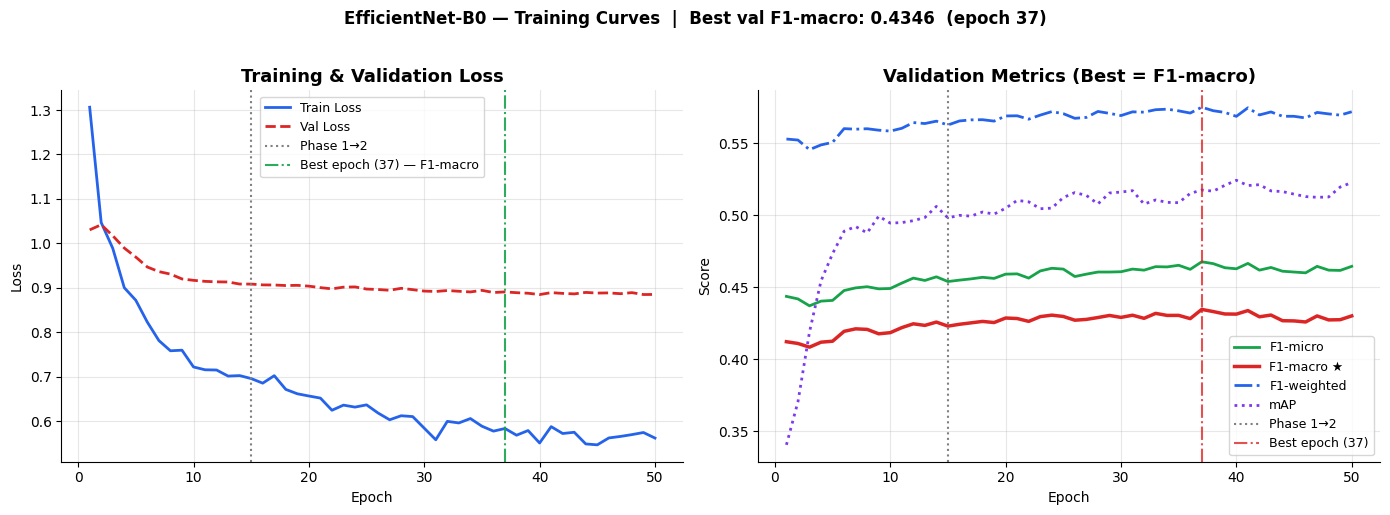

Plot disimpan.


In [10]:
# ════════════════════════════════════════════════════════════
# CELL 10 — Plot kurva training
# ════════════════════════════════════════════════════════════

ep = range(1, TOTAL_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#2563EB', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#DC2626', lw=2, ls='--')
axes[0].axvline(x=PHASE1_EPOCHS, color='gray',   ls=':', lw=1.5, label='Phase 1→2')
axes[0].axvline(x=best_epoch,    color='#16A34A', ls='-.', lw=1.5,
                label=f'Best epoch ({best_epoch}) — F1-macro', alpha=0.9)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(ep, history['val_f1_micro'],    label='F1-micro',    color='#16A34A', lw=2)
axes[1].plot(ep, history['val_f1_macro'],    label='F1-macro ★',  color='#DC2626', lw=2.5)
axes[1].plot(ep, history['val_f1_weighted'], label='F1-weighted',  color='#2563EB', lw=2, ls='-.')
axes[1].plot(ep, history['val_mAP'],         label='mAP',          color='#7C3AED', lw=2, ls=':')
axes[1].axvline(x=PHASE1_EPOCHS, color='gray', ls=':', lw=1.5, label='Phase 1→2')
axes[1].axvline(x=best_epoch, color='#DC2626', ls='-.', lw=1.5,
                label=f'Best epoch ({best_epoch})', alpha=0.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics (Best = F1-macro)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(
    f'{MODEL_NAME} — Training Curves  |  '
    f'Best val F1-macro: {best_val_f1_macro:.4f}  (epoch {best_epoch})',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'/kaggle/working/{MODEL_NAME}_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print(f"Plot disimpan.")

In [11]:
# ════════════════════════════════════════════════════════════
# CELL 11 — Evaluasi final di test set
# ════════════════════════════════════════════════════════════

model.load_state_dict(best_weights)
print(f"Model terbaik (epoch {best_epoch}, F1-macro={best_val_f1_macro:.4f}) dimuat.\n")

infer = measure_inference_time(model, device, n_runs=100)
print(f"Waktu inferensi per gambar:")
print(f"  Mean : {infer['mean_ms']:.3f} ms | Std : {infer['std_ms']:.3f} ms")

avg_infer_ms = infer['mean_ms']

print(f"\nMengevaluasi di test set...")
test_m = evaluate_full(model, test_loader, criterion)

print_metrics_table(test_m, GENRE_COLS,
                    title=f"HASIL EVALUASI FINAL — {MODEL_NAME} — TEST SET")

print(f"\n  METRIK VALIDASI TERBAIK (epoch {best_epoch}):")
print(f"  {'─'*40}")
print(f"  {'Val Loss':<28}: {min(history['val_loss']):.4f}")
print(f"  {'F1 Micro':<28}: {max(history['val_f1_micro']):.4f}")
print(f"  {'F1 Macro (best)':<28}: {best_val_f1_macro:.4f}  ← dasar pemilihan model")
print(f"  {'F1 Weighted':<28}: {max(history['val_f1_weighted']):.4f}")

print(f"\n  EFISIENSI MODEL:")
print(f"  {'─'*40}")
print(f"  {'Jumlah Parameter':<28}: {total_params:,}")
print(f"  {'Training time/epoch':<28}: {avg_epoch_time:.1f} detik")
print(f"  {'Inference time/gambar':<28}: {infer['mean_ms']:.3f} ms ± {infer['std_ms']:.3f} ms")

# Simpan val_m_final untuk dipakai di cell simpan hasil
val_m_final = evaluate_full(model, val_loader, criterion)

Model terbaik (epoch 37, F1-macro=0.4346) dimuat.

Waktu inferensi per gambar:
  Mean : 7.769 ms | Std : 0.303 ms

Mengevaluasi di test set...

══════════════════════════════════════════════════════════════════════
  HASIL EVALUASI FINAL — EfficientNet-B0 — TEST SET
══════════════════════════════════════════════════════════════════════

  METRIK PER GENRE:
  Genre         Precision   Recall       F1   Support
  ────────────────────────────────────────────────────
  action           0.7143   0.9722   0.8235        36
  adventure        0.4651   0.9091   0.6154        22
  animation        0.2222   1.0000   0.3636         8
  comedy           0.3636   0.9231   0.5217        13
  crime            0.2889   1.0000   0.4483        13
  drama            0.6977   0.8824   0.7792        34
  family           0.1111   1.0000   0.2000         4 ← minoritas
  fantasy          0.2273   0.9091   0.3636        11
  horror           0.0682   1.0000   0.1277         3 ← minoritas
  musical          0.0

INFERENSI — Contoh Prediksi pada Test Set
Threshold  : 0.3
Seed       : 42
N sampel   : 10
✓ sample_indices dibuat dan disimpan ke: /kaggle/working/sample_indices.npy
  Indeks: [3, 4, 9, 19, 28, 32, 33, 39, 44, 49]

────────────────────────────────────────────────────────────


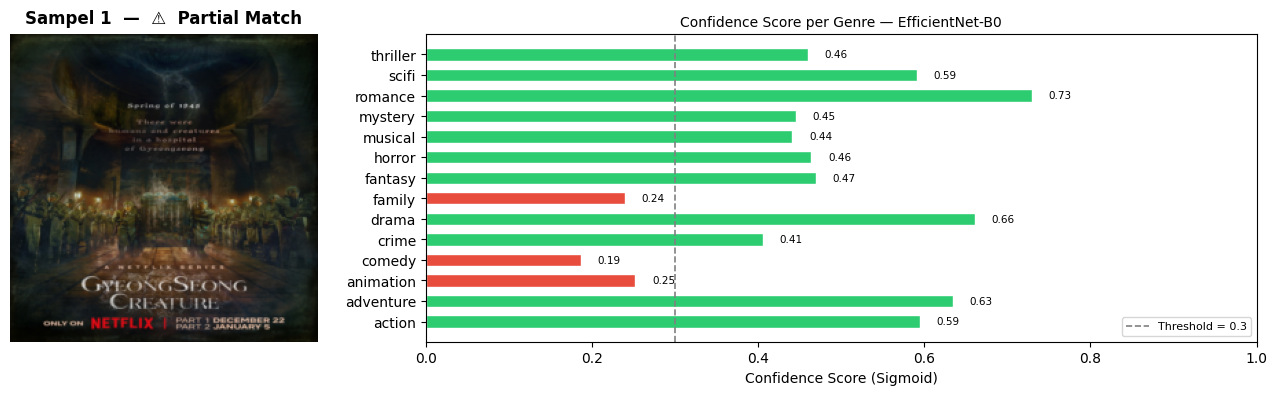


Sampel 1:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'drama', 'horror', 'mystery', 'thriller']
  Prediksi     : ['action', 'adventure', 'crime', 'drama', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'drama', 'horror', 'mystery', 'thriller']
  Salah  (FP)  : ['adventure', 'crime', 'fantasy', 'musical', 'romance', 'scifi']
────────────────────────────────────────────────────────────


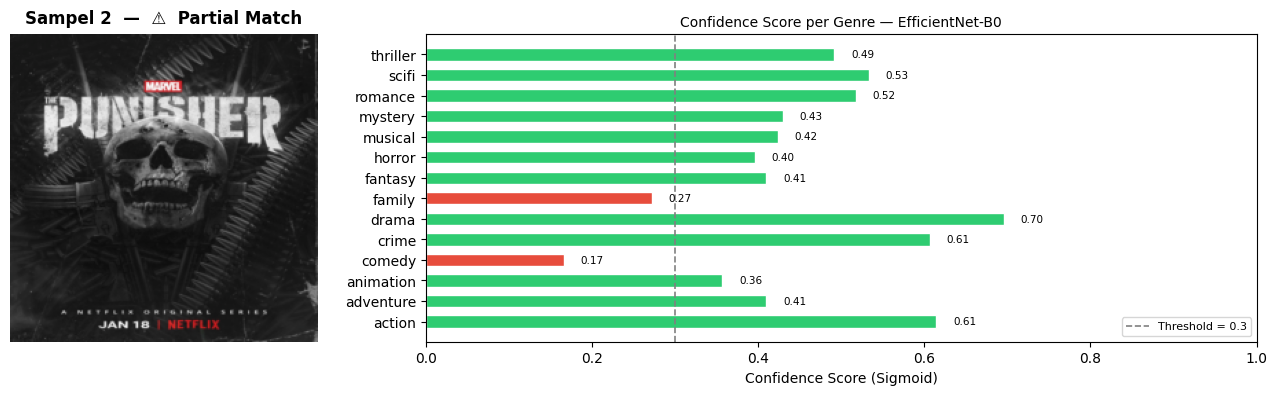


Sampel 2:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'thriller']
  Prediksi     : ['action', 'adventure', 'animation', 'crime', 'drama', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'crime', 'drama', 'thriller']
  Salah  (FP)  : ['adventure', 'animation', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi']
────────────────────────────────────────────────────────────


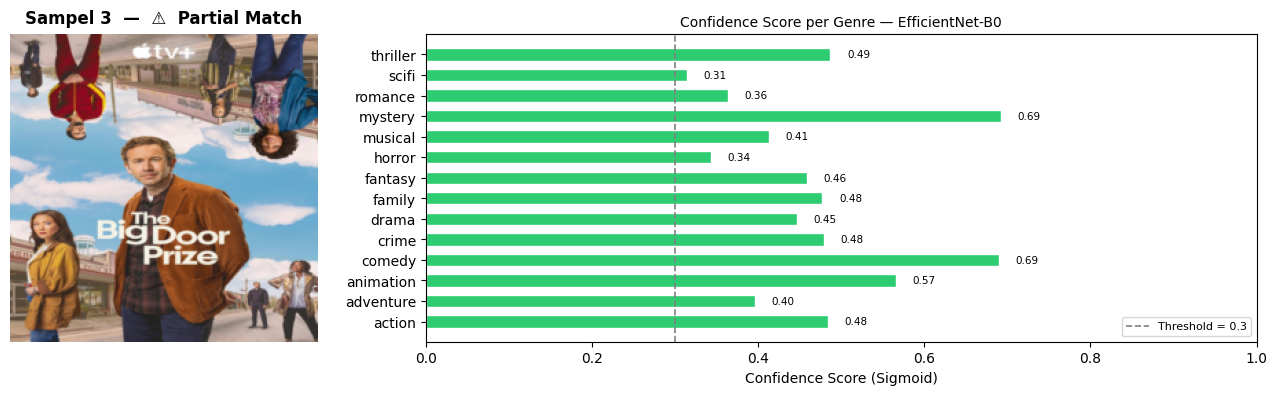


Sampel 3:
  Status       : ⚠️  Partial Match
  Label asli   : ['comedy', 'drama', 'mystery', 'scifi']
  Prediksi     : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['comedy', 'drama', 'mystery', 'scifi']
  Salah  (FP)  : ['action', 'adventure', 'animation', 'crime', 'family', 'fantasy', 'horror', 'musical', 'romance', 'thriller']
────────────────────────────────────────────────────────────


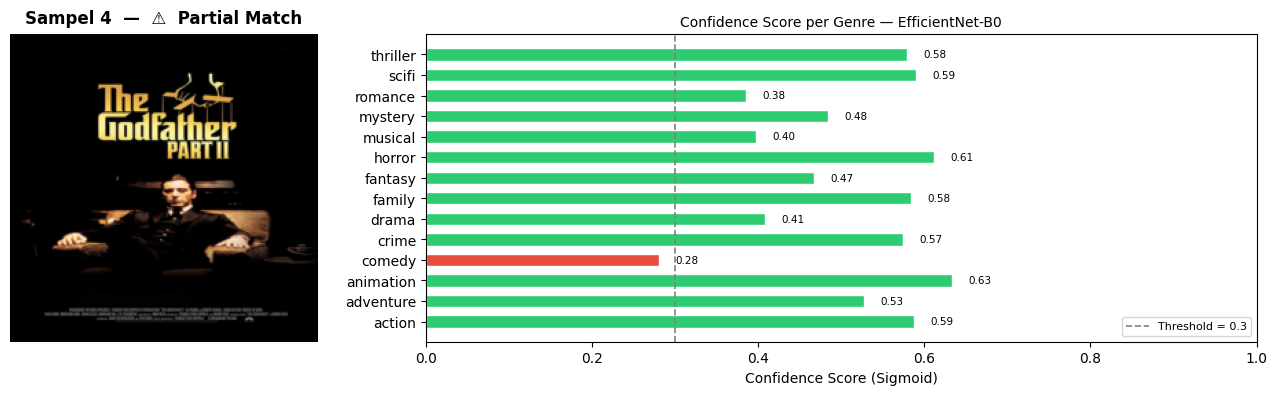


Sampel 4:
  Status       : ⚠️  Partial Match
  Label asli   : ['crime', 'drama']
  Prediksi     : ['action', 'adventure', 'animation', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['crime', 'drama']
  Salah  (FP)  : ['action', 'adventure', 'animation', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
────────────────────────────────────────────────────────────


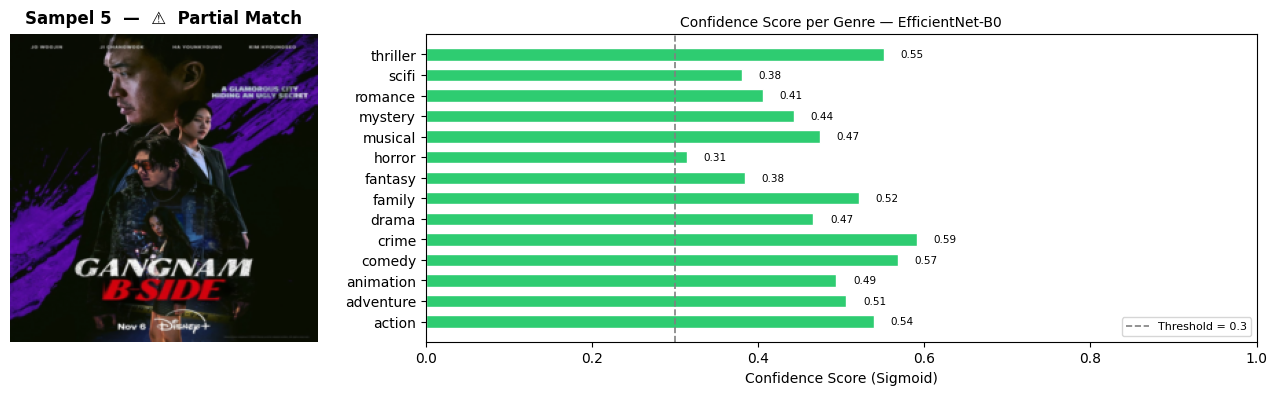


Sampel 5:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'mystery', 'thriller']
  Prediksi     : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'crime', 'drama', 'mystery', 'thriller']
  Salah  (FP)  : ['adventure', 'animation', 'comedy', 'family', 'fantasy', 'horror', 'musical', 'romance', 'scifi']
────────────────────────────────────────────────────────────


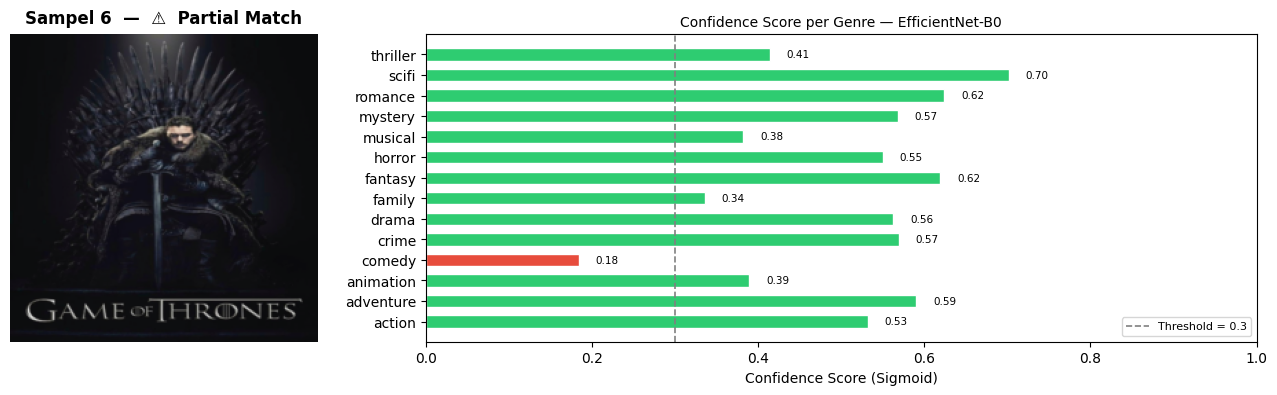


Sampel 6:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'fantasy']
  Prediksi     : ['action', 'adventure', 'animation', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'adventure', 'fantasy']
  Salah  (FP)  : ['animation', 'crime', 'drama', 'family', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
────────────────────────────────────────────────────────────


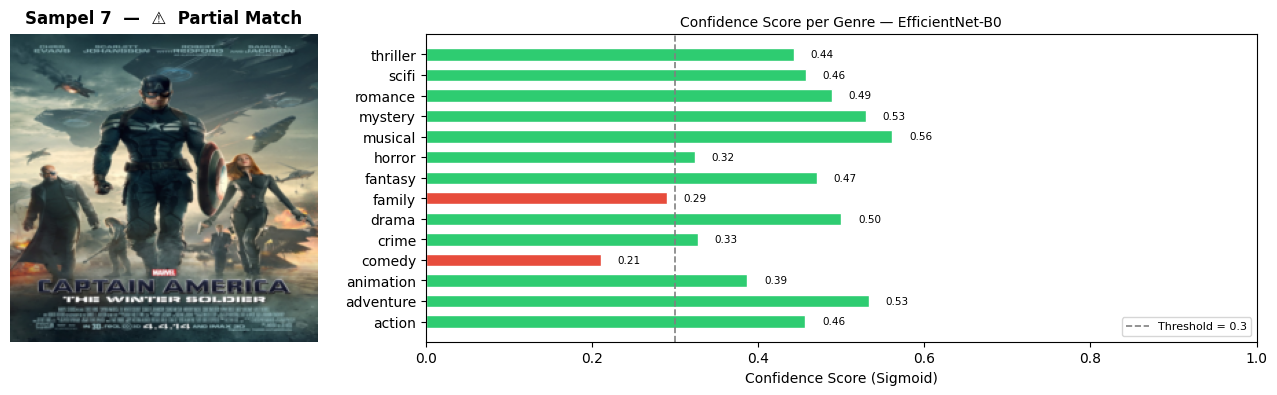


Sampel 7:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi', 'thriller']
  Prediksi     : ['action', 'adventure', 'animation', 'crime', 'drama', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'adventure', 'scifi', 'thriller']
  Salah  (FP)  : ['animation', 'crime', 'drama', 'fantasy', 'horror', 'musical', 'mystery', 'romance']
────────────────────────────────────────────────────────────


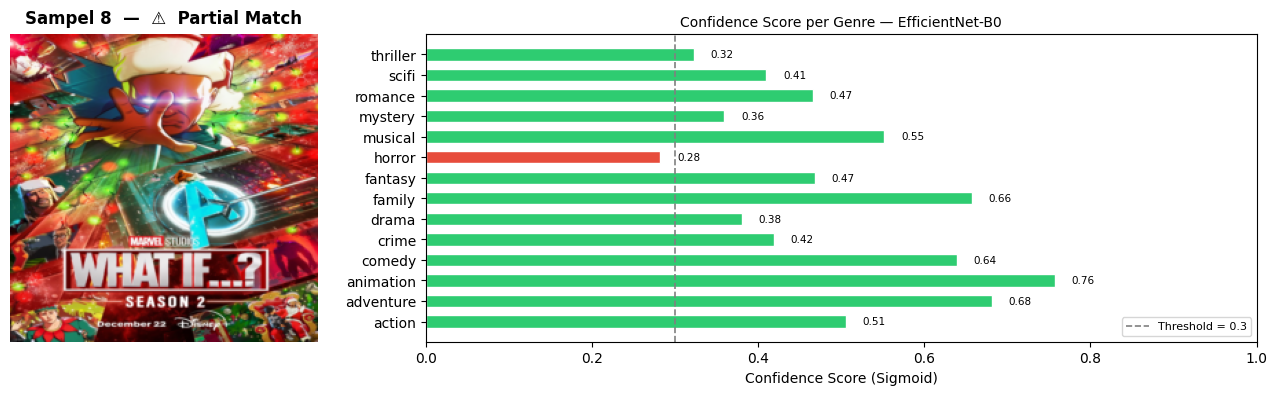


Sampel 8:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'animation', 'scifi']
  Prediksi     : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'adventure', 'animation', 'scifi']
  Salah  (FP)  : ['comedy', 'crime', 'drama', 'family', 'fantasy', 'musical', 'mystery', 'romance', 'thriller']
────────────────────────────────────────────────────────────


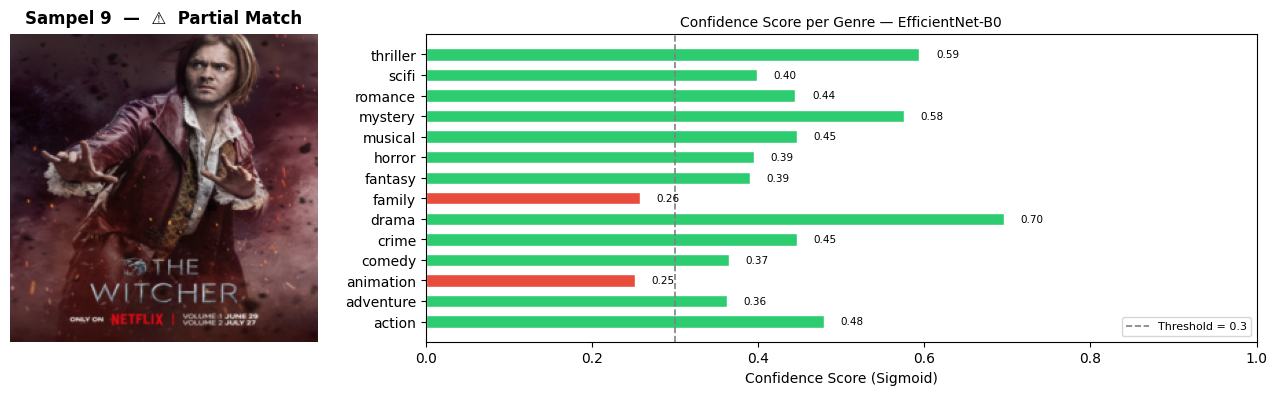


Sampel 9:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'drama']
  Prediksi     : ['action', 'adventure', 'comedy', 'crime', 'drama', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'adventure', 'drama']
  Salah  (FP)  : ['comedy', 'crime', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
────────────────────────────────────────────────────────────


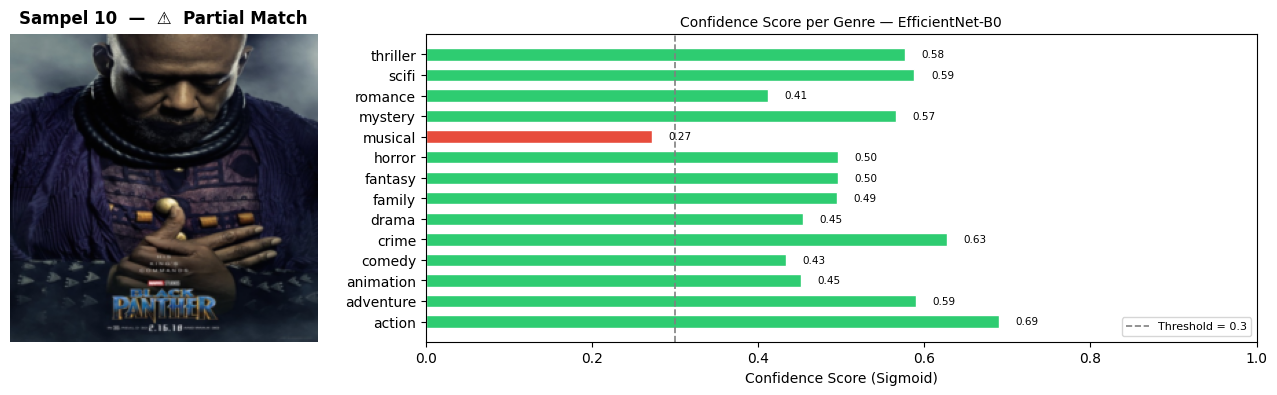


Sampel 10:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi']
  Prediksi     : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'mystery', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'adventure', 'scifi']
  Salah  (FP)  : ['animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'mystery', 'romance', 'thriller']
────────────────────────────────────────────────────────────


In [12]:
# ════════════════════════════════════════════════════════════
# CELL 12 — Inferensi dengan fixed seed (data test seragam)
# ════════════════════════════════════════════════════════════
# - Pemilihan sampel menggunakan fixed seed → data test SAMA
#   untuk DenseNet121, ResNet50, dan EfficientNet-B0
# - Load sample_indices.npy dari dataset temanmu jika tersedia
# - Tampilkan poster + confidence bar per genre

INFER_SEED   = 42
N_SAMPLES    = 10
INDICES_SAVE = '/kaggle/working/sample_indices.npy'

print(f"INFERENSI — Contoh Prediksi pada Test Set")
print(f"Threshold  : {THRESHOLD}")
print(f"Seed       : {INFER_SEED}")
print(f"N sampel   : {N_SAMPLES}")
print("=" * 60)

# ── Load dari dataset temanmu jika ada, generate jika tidak ──
if os.path.exists(INDICES_PATH_INPUT):
    sample_indices = np.load(INDICES_PATH_INPUT)
    print(f"✓ Loaded sample_indices dari dataset input: {INDICES_PATH_INPUT}")
elif os.path.exists(INDICES_SAVE):
    sample_indices = np.load(INDICES_SAVE)
    print(f"✓ Loaded sample_indices dari working: {INDICES_SAVE}")
else:
    rng            = np.random.default_rng(INFER_SEED)
    sample_indices = rng.choice(len(X_test), size=N_SAMPLES, replace=False)
    sample_indices = np.sort(sample_indices)
    np.save(INDICES_SAVE, sample_indices)
    print(f"✓ sample_indices dibuat dan disimpan ke: {INDICES_SAVE}")

print(f"  Indeks: {sample_indices.tolist()}")
print()

# ── Inferensi ────────────────────────────────────────────────
model.eval()
sample_imgs   = X_test[sample_indices].to(device)
sample_labels = y_test[sample_indices].numpy().astype(int)

with torch.no_grad():
    sample_outputs = model(sample_imgs)
    sample_probs   = torch.sigmoid(sample_outputs).cpu().numpy()

sample_preds = (sample_probs > THRESHOLD).astype(int)

# ── Denormalisasi untuk visualisasi ──────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor_img):
    img = tensor_img.cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# ── Tampilkan hasil per sampel ───────────────────────────────
print(f"{'─'*60}")

for idx in range(N_SAMPLES):
    true_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_labels[idx][i] == 1]
    pred_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_preds[idx][i]  == 1]
    correct = set(true_genres) & set(pred_genres)
    missed  = set(true_genres) - set(pred_genres)
    false_p = set(pred_genres) - set(true_genres)

    if set(true_genres) == set(pred_genres):
        status = "✅ Exact Match"
    elif correct:
        status = "⚠️  Partial Match"
    else:
        status = "❌ Wrong"

    # ── Gambar poster + confidence bar ───────────────────────
    fig = plt.figure(figsize=(13, 4))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], figure=fig)

    ax_img = fig.add_subplot(gs[0])
    poster_np = denormalize(X_test[sample_indices[idx]])
    ax_img.imshow(poster_np)
    ax_img.axis('off')
    ax_img.set_title(
        f"Sampel {idx + 1}  —  {status}",
        fontsize=12, fontweight='bold', pad=8
    )

    ax_bar = fig.add_subplot(gs[1])
    probs  = sample_probs[idx]
    colors = ['#2ecc71' if probs[i] > THRESHOLD else '#e74c3c'
              for i in range(N_GENRES)]
    bars = ax_bar.barh(GENRE_COLS, probs, color=colors,
                       edgecolor='white', height=0.6)
    ax_bar.axvline(x=THRESHOLD, color='gray', linestyle='--',
                   linewidth=1.2, label=f'Threshold = {THRESHOLD}')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel('Confidence Score (Sigmoid)')
    ax_bar.set_title(f'Confidence Score per Genre — {MODEL_NAME}', fontsize=10)
    ax_bar.legend(fontsize=8, loc='lower right')

    for bar, prob in zip(bars, probs):
        ax_bar.text(
            min(prob + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
            f'{prob:.2f}', va='center', ha='left', fontsize=7.5
        )

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/inferensi_sampel_{idx+1}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

    print(f"\nSampel {idx + 1}:")
    print(f"  Status       : {status}")
    print(f"  Label asli   : {true_genres}")
    print(f"  Prediksi     : {pred_genres}")
    print(f"  Benar  (TP)  : {sorted(correct)}")
    if missed:
        print(f"  Terlewat(FN) : {sorted(missed)}")
    if false_p:
        print(f"  Salah  (FP)  : {sorted(false_p)}")
    print(f"{'─'*60}")

In [13]:
# ════════════════════════════════════════════════════════════
# CELL 13 — Simpan semua hasil ke file
# ════════════════════════════════════════════════════════════

results_path = f'/kaggle/working/{MODEL_NAME}_results.pt'

torch.save({
    "model_name"              : MODEL_NAME,
    "best_weights"            : best_weights,
    "best_epoch"              : best_epoch,
    "total_params"            : total_params,
    "avg_epoch_time_s"        : avg_epoch_time,
    "avg_infer_ms"            : avg_infer_ms,
    "threshold"               : THRESHOLD,
    "val_loss"                : val_m_final['loss'],
    "test_loss"               : test_m['loss'],
    "test_f1_micro"           : test_m['f1_micro'],
    "test_f1_macro"           : test_m['f1_macro'],
    "test_f1_weighted"        : test_m['f1_weighted'],
    "test_f1_per_genre"       : test_m['f1_per_genre'],
    "test_precision_per_genre": test_m['precision_per_genre'],
    "test_recall_per_genre"   : test_m['recall_per_genre'],
    "test_support_per_genre"  : test_m['support_per_genre'],
    "test_precision_micro"    : test_m['precision_micro'],
    "test_precision_macro"    : test_m['precision_macro'],
    "test_precision_weighted" : test_m['precision_weighted'],
    "test_recall_micro"       : test_m['recall_micro'],
    "test_recall_macro"       : test_m['recall_macro'],
    "test_recall_weighted"    : test_m['recall_weighted'],
    "test_mAP"                : test_m['mAP'],
    "test_auc_roc"            : test_m['auc_roc'],
    "test_hamming_loss"       : test_m['hamming_loss'],
    "test_exact_match"        : test_m['exact_match'],
    "history"                 : history,
    "genre_cols"              : GENRE_COLS,
    "phase1_epochs"           : PHASE1_EPOCHS,
    "phase2_epochs"           : PHASE2_EPOCHS,
    "total_epochs"            : TOTAL_EPOCHS,
    "sample_indices"          : sample_indices.tolist(),
}, results_path)

print(f"Semua hasil tersimpan : {results_path}")
print(f"\n{'═'*60}")
print(f"  RINGKASAN AKHIR — {MODEL_NAME}")
print(f"{'═'*60}")
print(f"  Best metric     : Val F1-macro (epoch {best_epoch})")
print(f"  Threshold       : {THRESHOLD} (seragam semua model)")
print(f"  Total epoch     : {TOTAL_EPOCHS} ({PHASE1_EPOCHS}+{PHASE2_EPOCHS})")
print(f"  Parameter       : {total_params:,}")
print(f"  Train time/epoch: {avg_epoch_time:.1f}s")
print(f"  Infer time/img  : {avg_infer_ms:.3f}ms")
print(f"\n  — TEST SET METRICS —")
print(f"  Val Loss        : {val_m_final['loss']:.4f}")
print(f"  Test Loss       : {test_m['loss']:.4f}")
print(f"  F1 Micro        : {test_m['f1_micro']:.4f}")
print(f"  F1 Macro        : {test_m['f1_macro']:.4f}")
print(f"  F1 Weighted     : {test_m['f1_weighted']:.4f}")
print(f"  Hamming Loss    : {test_m['hamming_loss']:.4f}")
print(f"  Exact Match     : {test_m['exact_match']:.4f}")
print(f"  AUC-ROC         : {test_m['auc_roc']:.4f}")
print(f"  mAP (macro)     : {test_m['mAP']:.4f}")
print(f"{'═'*60}")
print(f"\nSelesai. Klik Save Version untuk menyimpan notebook.")

Semua hasil tersimpan : /kaggle/working/EfficientNet-B0_results.pt

════════════════════════════════════════════════════════════
  RINGKASAN AKHIR — EfficientNet-B0
════════════════════════════════════════════════════════════
  Best metric     : Val F1-macro (epoch 37)
  Threshold       : 0.3 (seragam semua model)
  Total epoch     : 50 (15+35)
  Parameter       : 4,025,482
  Train time/epoch: 0.8s
  Infer time/img  : 7.769ms

  — TEST SET METRICS —
  Val Loss        : 0.8911
  Test Loss       : 0.8160
  F1 Micro        : 0.4586
  F1 Macro        : 0.4141
  F1 Weighted     : 0.5995
  Hamming Loss    : 0.6171
  Exact Match     : 0.0000
  AUC-ROC         : 0.6653
  mAP (macro)     : 0.4619
════════════════════════════════════════════════════════════

Selesai. Klik Save Version untuk menyimpan notebook.
